# EIA Phase-0 — data, encoding, and the spiking classifier

Thin notebook: all logic lives in the `eia` package. Runs **locally** (VSCode/Jupyter on your M-series Mac via MPS) or on **Google Colab** (GPU).

It shows, for a chosen modality (ECG or PPG):
1. a **data card** — exactly what's being trained on, with warnings,
2. **example waveforms** per class,
3. the **delta encoding** scheme the SNN receives,
4. training + an accuracy/energy result.

## Setup
On Colab this clones the repo + installs deps. Locally it's a no-op if `eia` already imports.

In [1]:
import importlib.util, sys, subprocess, os

if importlib.util.find_spec('eia') is None:
    if 'google.colab' in sys.modules:
        # EDIT to your GitHub repo URL after you push:
        REPO = 'https://github.com/USERNAME/eia.git'
        subprocess.run(['git', 'clone', REPO], check=True)
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', 'eia'], check=True)
        sys.path.insert(0, 'eia/src')
    else:
        sys.path.insert(0, os.path.abspath('../src'))

import eia
print('eia', eia.__version__)

eia 0.1.0


## Choose a modality and load the data

In [2]:
from eia.datasets import load_ecg, load_ppg

MODALITY = 'ppg'        # 'ecg' or 'ppg'
PREFER_REAL = False     # True -> MIT-BIH (ecg) / BIDMC (ppg); needs wfdb + network

data = load_ppg(prefer_real=PREFER_REAL) if MODALITY == 'ppg' else load_ecg(prefer_real=PREFER_REAL)
print('source:', data.source, '| X:', data.X.shape)

source: synthetic | X: (2000, 125)


## 1. Data card — what are we actually training on?
Prints the source, label definition, class balance, base rate, and any red-flag warnings (imbalance, tiny N, high base rate). One card per dataset — never pooled.

In [3]:
from eia import report
card = report.data_card(data)

 DATA CARD — PPG / synthetic
 samples        : 2000
 window         : 125 samples  (~1.00s @ 125 Hz)
 class balance  : {0: 0.617, 1: 0.383}  (counts {0: 1234, 1: 766})
 majority base  : 0.617  (a model at this accuracy has learned nothing)
 label          : 0 = normovolemic pulse, 1 = hypovolemic (reduced amplitude, blunted dicrotic notch) — a Compensatory-Reserve-style waveform change.
 limitations    : Synthetic. Closest generator to the real hemorrhage target, but not real physiology.


## 2. Example waveforms per class
What one window looks like for each class (e.g. normovolemic vs hypovolemic PPG pulse, or normal vs PVC ECG beat).

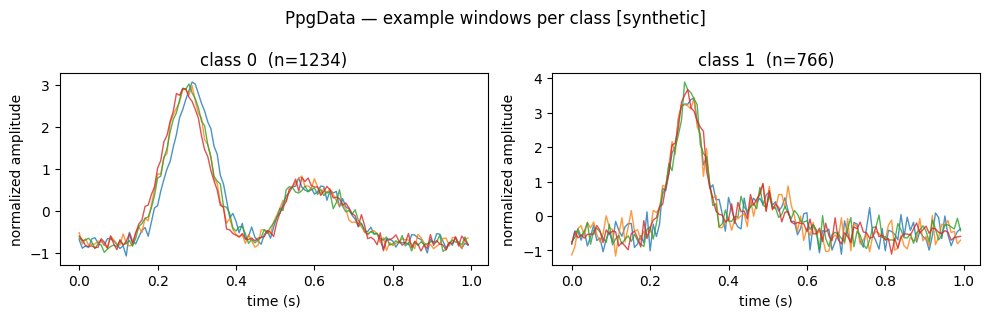

In [4]:
from eia import viz
_ = viz.plot_waveforms(data, n_per_class=4)

## 3. The delta encoding scheme
How a continuous window becomes the sparse ON/OFF spike raster the SNN receives. Panel 1: signal + threshold bands. Panel 2: delta events. Panel 3: the 2-channel input raster (channels × timesteps) — this is exactly the Xylo input framing.

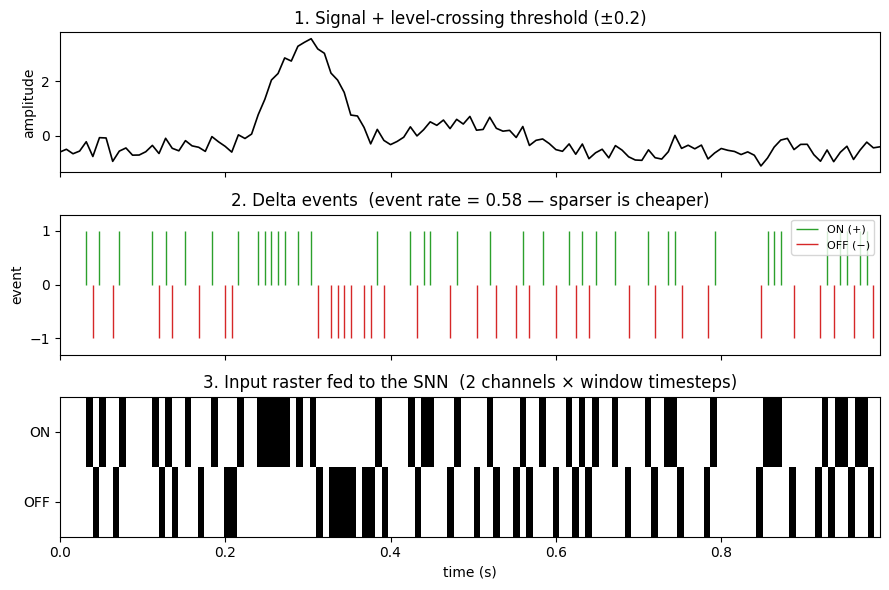

In [5]:
import numpy as np
# pick one 'abnormal' (class-1) example to encode
i = int(np.where(np.asarray(data.y) == 1)[0][0])
_ = viz.plot_encoding(data.X[i], threshold=0.2, fs=data.fs)

## 4. Train SNN + baseline, compare accuracy and energy
Uses `eia.train.run`. On synthetic data this takes well under a minute on an M-series Mac. Note the data card above when reading accuracy: synthetic is easy by design (~1.0); use real data for a meaningful number.

In [6]:
from eia.train import run
results = run(real=PREFER_REAL, epochs=10, device_pref='auto', modality=MODALITY)

# re-print the card with the model's accuracy, to flag 'not learning' vs base rate
_ = report.data_card(data, model_acc=results['snn_acc'])
results

[device] mps
[data] modality=ppg  source=synthetic  X=(2000, 125)  pos_frac=0.38  fs=125.0Hz
[encoding] mean input event rate = 0.177



===== RESULTS =====
Baseline (dense)  accuracy : 1.000
SNN (event-driven) accuracy: 1.000
SNN mean hidden spike rate : 0.137
SNN train time             : 1.7s (10 epochs)
-------------------
Dense baseline : 48,640 MACs  ->  0.151 uJ
Event-driven   : 133,388 SOPs  ->  0.120 uJ
Energy ratio   : 1.3x cheaper (event-driven)
 DATA CARD — PPG / synthetic
 samples        : 2000
 window         : 125 samples  (~1.00s @ 125 Hz)
 class balance  : {0: 0.617, 1: 0.383}  (counts {0: 1234, 1: 766})
 majority base  : 0.617  (a model at this accuracy has learned nothing)
 label          : 0 = normovolemic pulse, 1 = hypovolemic (reduced amplitude, blunted dicrotic notch) — a Compensatory-Reserve-style waveform change.
 limitations    : Synthetic. Closest generator to the real hemorrhage target, but not real physiology.


{'baseline_acc': 1.0,
 'snn_acc': 1.0,
 'mean_rate': 0.13711796700954437,
 'energy_ratio': 1.256018365803354,
 'source': 'synthetic',
 'timesteps': 20,
 'threshold': 0.25,
 'modality': 'ppg'}

## Next
- Flip `PREFER_REAL = True` to pull real data (MIT-BIH / BIDMC).
- `--sweep` in `eia.train` traces the accuracy/energy trade-off.
- Xylo deployment + bit-precise verification: `python scripts/xylo_verify.py` (see `docs/xylo_verification_task.md`).